In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
hour_df = pd.read_csv('hour.csv')
day_df = pd.read_csv('day.csv')

In [3]:
display(hour_df)
display(day_df)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [4]:
hour_df.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000


In [5]:
hour_df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

### Correlation Heatmap

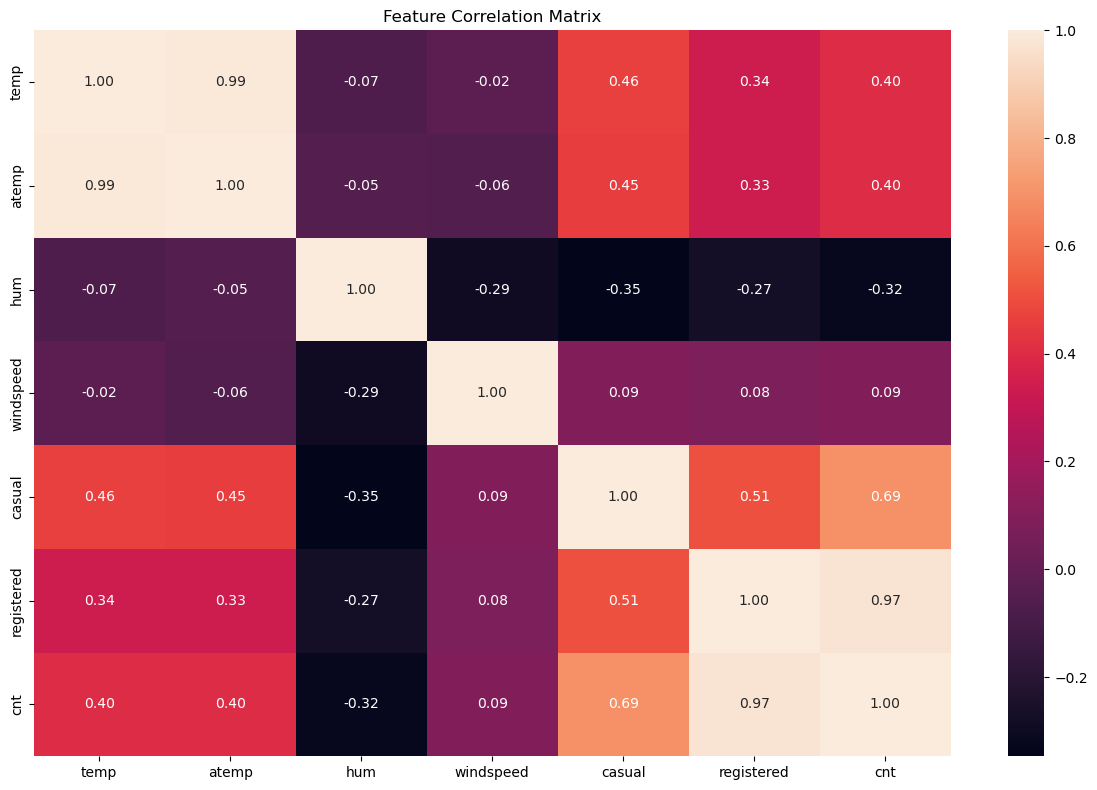

In [6]:
plt.figure(figsize=(12,8))
correlation = hour_df[['temp', 'atemp', 'hum','windspeed','casual','registered','cnt']].corr()

sns.heatmap(correlation, annot=True, fmt = '.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Humidity Distribution')

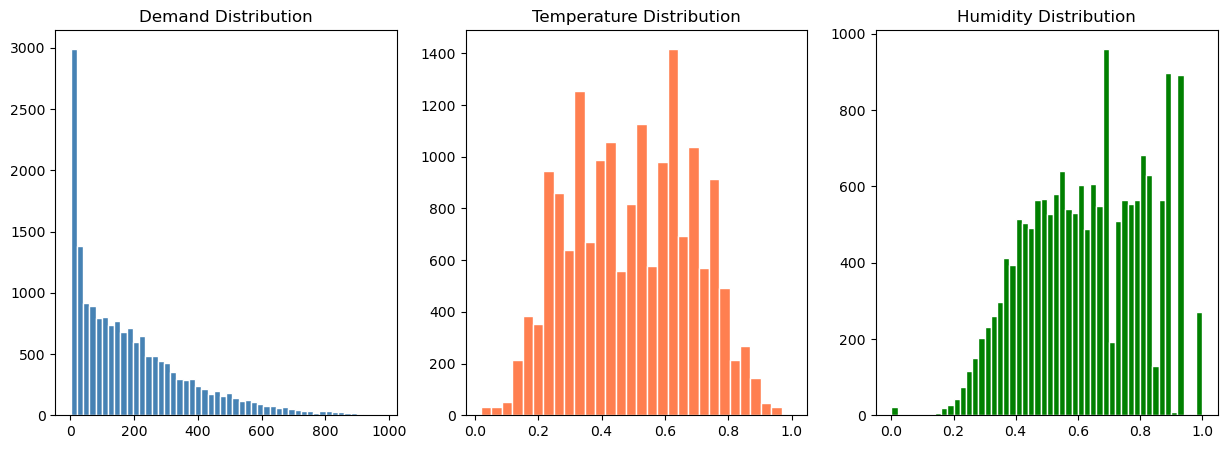

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].hist(hour_df['cnt'], bins = 50, color = 'steelblue', edgecolor = 'white')
axes[0].set_title('Demand Distribution')

axes[1].hist(hour_df['temp'], bins = 30, color = 'coral', edgecolor = 'white')
axes[1].set_title('Temperature Distribution')

axes[2].hist(hour_df['hum'], bins = 50, color = 'green', edgecolor = 'white')
axes[2].set_title('Humidity Distribution')


### Feature Engineering

In [8]:
hour_df['is_weekend'] = hour_df['weekday'].apply(lambda x : 1 if x in [0,6] else 0)

hour_df['rush_hour'] = hour_df['hr'].apply(lambda x : 1 if x in [7,8,9,17,18,19] else 0)

hour_df['temp_category'] = pd.cut(hour_df['temp'], bins = [0, 0.3, 0.6, 1.0], labels = ['Cold', 'Moderate', 'Hot'])

### ML Model

In [9]:
from sklearn.model_selection import train_test_split

features = ['season', 'hr', 'holiday', 'weekday', 'weathersit', 'temp', 'hum', 'windspeed', 'is_weekend', 'rush_hour']

x = hour_df[features]
y = hour_df['cnt']

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size = 0.2, random_state= 42)

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


model  = RandomForestRegressor( n_estimators = 100, random_state = 42 )

model.fit(x_train, y_train)

pred = model.predict(x_test)

r2 = round(r2_score(y_test, pred), 3)
mae = round(mean_absolute_error(y_test, pred), 1)

print(f"R2 Score : {r2}")
print(f"MAE : {mae} rentals")

R2 Score : 0.858
MAE : 43.1 rentals


In [11]:
model  = RandomForestRegressor( n_estimators = 200,
                               max_depth = 15, 
                               min_samples_split = 5, 
                               random_state = 42 )

model.fit(x_train, y_train)

pred = model.predict(x_test)

r2 = round(r2_score(y_test, pred), 3)
mae = round(mean_absolute_error(y_test, pred), 1)

print(f"R2 Score : {r2}")
print(f"MAE : {mae} rentals")

R2 Score : 0.859
MAE : 43.8 rentals


In [12]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, x, y, cv = 5, scoring = 'r2')

print(f'cv r2 scores : {scores}')
print(f'average : {scores.mean().round(3)}')

cv r2 scores : [0.22258861 0.41284464 0.47133897 0.71479603 0.71717401]
average : 0.508


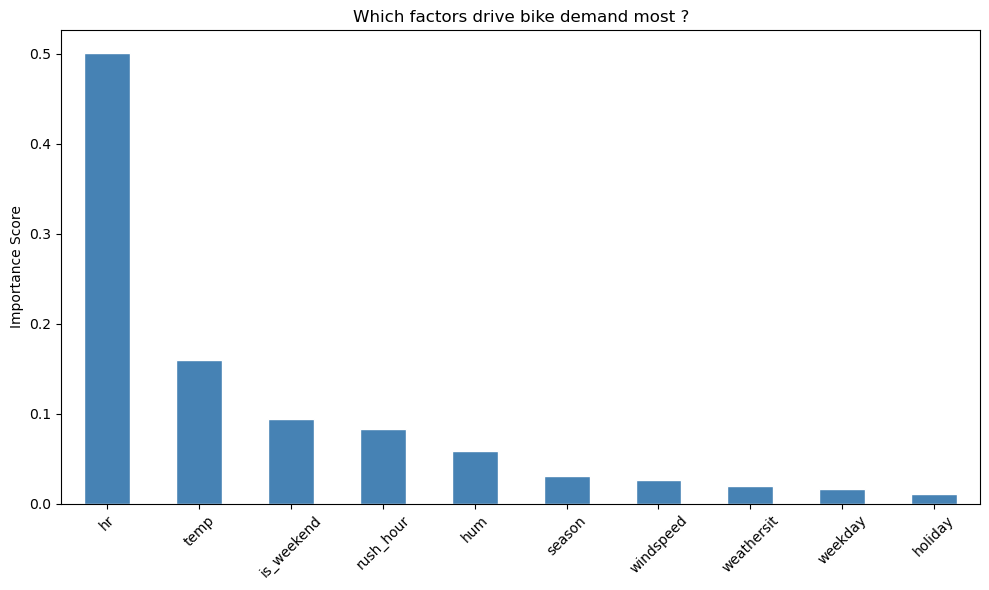

In [13]:
feat_imp = pd.Series(
    model.feature_importances_, index = features).sort_values(ascending=False)

plt.figure(figsize= (10,6))
feat_imp.plot(kind = 'bar', color = 'steelblue', edgecolor = 'white')
plt.title('Which factors drive bike demand most ?')
plt.ylabel('Importance Score')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

### Actual vs Predicted Plot

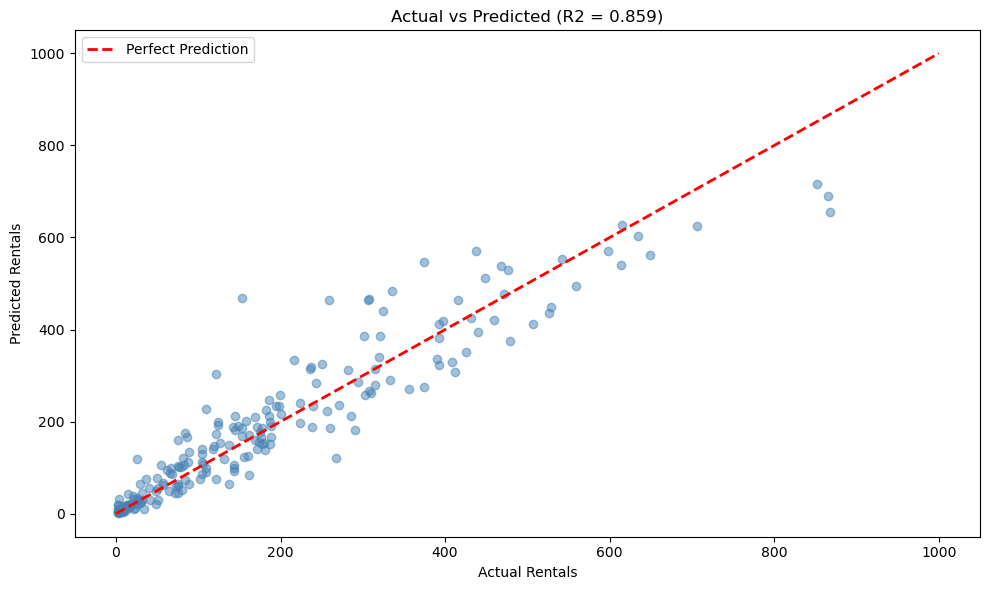

In [14]:
plt.figure(figsize = (10,6))
plt.scatter(y_test[:200], pred[:200], alpha = 0.5, color = 'steelblue')
plt.plot([0,1000], [0,1000], 'r--', linewidth = 2, label = 'Perfect Prediction')
plt.xlabel('Actual Rentals')
plt.ylabel('Predicted Rentals')
plt.title(f'Actual vs Predicted (R2 = {r2})')
plt.legend()
plt.tight_layout()
plt.show()

### Residual Analysis

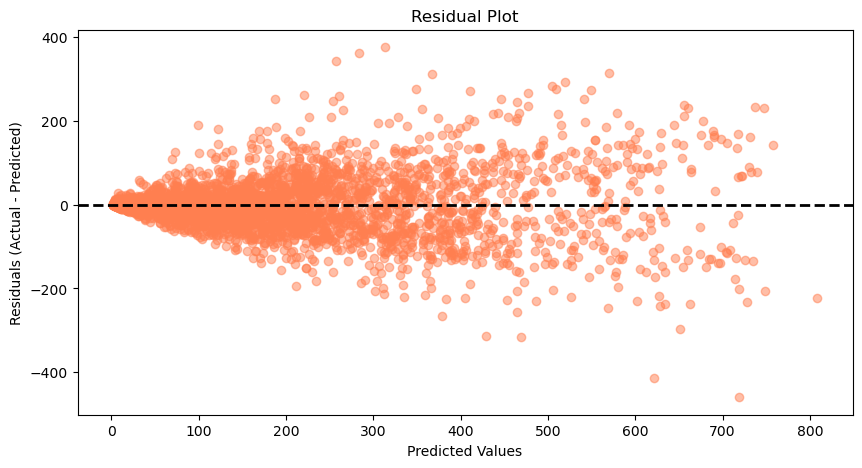

In [15]:
residuals = y_test - pred

plt.figure(figsize=(10,5))
plt.scatter(pred, residuals, 
            alpha=0.5, color='coral')
plt.axhline(y=0, color='black', 
            linewidth=2, linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

### Model Comparision

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

results = {}
for name, m in models.items():
    m.fit(x_train, y_train)
    p = m.predict(x_test)
    results[name] = {
        'R2': round(r2_score(y_test, p), 3),
        'MAE': round(mean_absolute_error(y_test, p), 1)
    }

results_df = pd.DataFrame(results).T
print(results_df)

                      R2   MAE
Linear Regression  0.514  92.1
Decision Tree      0.739  55.0
Random Forest      0.858  43.1
XGBoost            0.867  43.6


### Error Analysis

In [19]:
hour_df_test = x_test.copy()
hour_df_test['actual'] = y_test.values
hour_df_test['predicted'] = pred
hour_df_test['error'] = abs( hour_df_test['actual'] - hour_df_test['predicted'])

# Worst hours
print("Worst prediction hours:")
print(hour_df_test.groupby('hr')['error'].mean().sort_values(ascending=False).head(5))

# Worst weather
print("Worst prediction weather:")
print(hour_df_test.groupby('weathersit')['error'].mean().sort_values(ascending=False))

Worst prediction hours:
hr
18    98.911558
17    97.346905
8     96.780033
19    74.194385
16    70.085788
Name: error, dtype: float64
Worst prediction weather:
weathersit
3    46.319301
2    44.488111
1    43.287262
4     3.688274
Name: error, dtype: float64


In [20]:
import joblib

# Save
joblib.dump(model, 'bike_demand_model.pkl')

# Load aur use karo
loaded_model = joblib.load('bike_demand_model.pkl')

# Predict new data
new_data = pd.DataFrame({
    'season': [3],      # Summer
    'hr': [8],          # 8am
    'holiday': [0],     # Not holiday
    'weekday': [1],     # Monday
    'weathersit': [1],  # Clear
    'temp': [0.7],      # Warm
    'hum': [0.5],       # Normal humidity
    'windspeed': [0.2], # Light wind
    'is_weekend': [0],  # Weekday
    'rush_hour': [1]    # Rush hour
})

prediction = loaded_model.predict(new_data)
print(f"Predicted rentals: {round(prediction[0])} bikes")

Predicted rentals: 508 bikes


In [21]:
print("""
=== BUSINESS INSIGHTS ===

1. STAFFING:
   Deploy maximum bikes at 8am and 5-6pm
   Reduce deployment after 10pm

2. WEATHER POLICY:
   Clear weather → Full fleet deployment
   Heavy rain → Reduce by 65%

3. SEASONAL PLANNING:
   Summer: Maximum inventory
   Winter: Reduce fleet by 50%

4. WEEKEND vs WEEKDAY:
   Weekday: Focus on commute hours
   Weekend: Focus on afternoon 12-4pm

5. REVENUE OPPORTUNITY:
   Rush hours have 3x demand but same pricing
   Consider surge pricing at 8am and 5pm
""")


=== BUSINESS INSIGHTS ===

1. STAFFING:
   Deploy maximum bikes at 8am and 5-6pm
   Reduce deployment after 10pm

2. WEATHER POLICY:
   Clear weather → Full fleet deployment
   Heavy rain → Reduce by 65%

3. SEASONAL PLANNING:
   Summer: Maximum inventory
   Winter: Reduce fleet by 50%

4. WEEKEND vs WEEKDAY:
   Weekday: Focus on commute hours
   Weekend: Focus on afternoon 12-4pm

5. REVENUE OPPORTUNITY:
   Rush hours have 3x demand but same pricing
   Consider surge pricing at 8am and 5pm

